In [ ]:
from deap import tools, creator, base, algorithms, benchmarks
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz4"
NOBJ = 4
K = 10
NDIM = NOBJ + K - 1
P = 6
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 800
NGEN = 300
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [ ]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        hv_val = hypervolume(pop, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                          	min                                                              	avg                                          	max                                          	hypervolume	igd_plus
0  	800  	[0.28347867 0.20231069 0.12115592 0.12221541]	[3.68251378e-003 0.00000000e+000 0.00000000e+000 1.00558026e-264]	[1.80026533 0.03182598 0.01823552 0.01631342]	[2.55344432 1.94976003 1.31772376 1.73177464]	           	        
1  	800  	[0.31997574 0.27339369 0.16015725 0.14687534]	[3.68251378e-003 0.00000000e+000 0.00000000e+000 1.00558026e-264]	[1.70079489 0.05058599 0.02431909 0.02137561]	[2.55344432 2.06056568 1.7913644  1.73177464]	0.0466678  	0.569214
2  	800  	[0.37778707 0.35945583 0.2074199  0.19514955]	[0.00368251 0.         0.         0.        ]                    	[1.59693443 0.08608231 0.03846941 0.03497963]	[2.4163144  2.19171963 1.7913644  1.73177464]	0.21506    	0.412073
3  	800  	[0.43399396 0.45879507 0.27823174 0.25938305]	[0.0

[0.9831902148909512, 0.9878545168261437, 0.9777772821572885, 0.5123595109163089, 0.49456325962357695, 0.4963158630759459, 0.5093922858386813, 0.4999226858231763, 0.4996025242831779, 0.5274315999066668, 0.5080302941821877, 0.5130170318882943, 0.49668499194118376]
[0.9872674983170608, 0.9916364797071374, 0.032276319948326304, 0.4896553354018367, 0.480485623868473, 0.5026302348478728, 0.5194299282606203, 0.5225678508761735, 0.5183672021510476, 0.4997449925555011, 0.4919740530683055, 0.5109427934768029, 0.4940498989481743]
[0.023120823602127326, 0.9926178839068651, 0.9972721617163424, 0.4995393847603799, 0.514786974639726, 0.49543072900339896, 0.4993326989427951, 0.4997155201370402, 0.5009990233106453, 0.49916602381753605, 0.4894751918902507, 0.5003321408791664, 0.4988400193532486]
[0.9936764020588128, 0.9800227374757683, 0.9965759486270277, 0.49724515775834105, 0.49509939381096607, 0.533633597217373, 0.49441705851199264, 0.5038314550954395, 0.4774346041608922, 0.49236916058314634, 0.50462

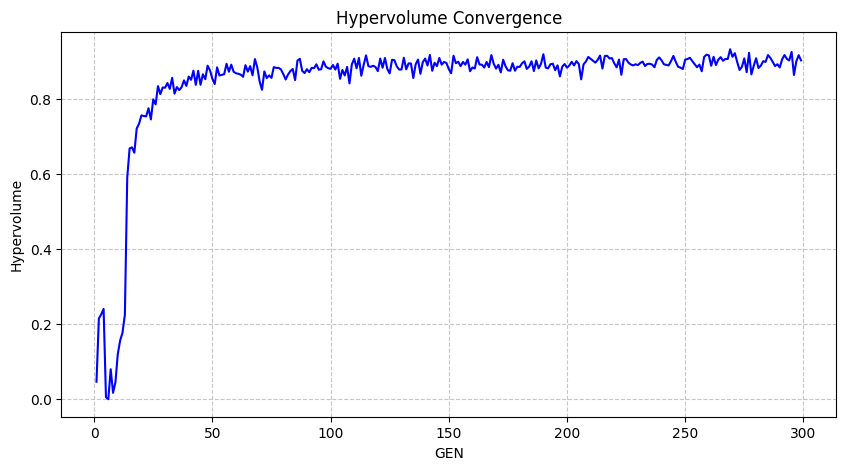

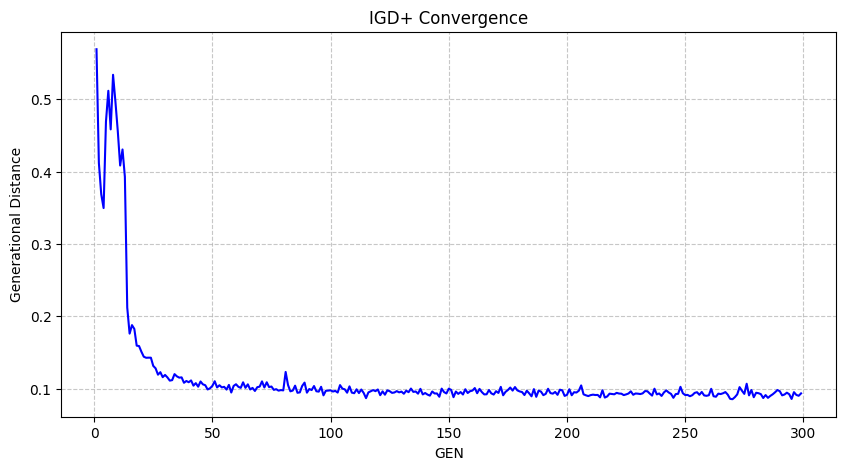

In [6]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()